Streaming

Methods: stream() and astream()

* These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state
* values: This streams the full state of the graph after each node is called.
* updates: This streams update to the state of the graph after each node is called.

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages #a reducer used to add messages to the state rather than replacing
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
class State(TypedDict):
    #Messages have the type "list". The "add_messages" function
    #in the annotation defines how this state key should be updated
    #(in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
llm = ChatOpenAI(
    model = "gpt-3.5-turbo"
)

In [4]:
def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [5]:
graph = StateGraph(State)

#node
graph.add_node("Superbot", superbot)

#edges
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

memory = MemorySaver()
graph_builder = graph.compile(checkpointer=memory)

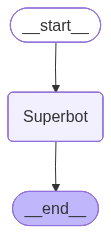

In [7]:
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
#Invocation
config = {"configurable": {"thread_id": "1"}}

response = graph_builder.invoke({"messages":"Hi, My name is Sora, and I like football"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi, My name is Sora, and I like football
================================== Ai Message ==================================

Hi Sora! That's great to hear that you like football. What is your favorite team or player?


In [ ]:
#Stream using "updates" -> only the last message is generated
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Sora, and I like football"}, 
                                  config=config,
                                  stream_mode="updates"):
    print(chunk)


{'Superbot': {'messages': [AIMessage(content="Hi Sora! That's great to hear that you like football. What do you enjoy most about the sport?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 19, 'total_tokens': 42, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DhHffjCNnu5SJCJaVIaatwdkl2lGB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e4116-0019-7831-bc49-f130672d48f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 23, 'total_tokens': 42, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [ ]:
#Stream using "values" -> the whole message chain is generated (for detailed information)
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages":"Hi, My name is Sora, and I like football"}, 
                                  config=config,
                                  stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Sora, and I like football', additional_kwargs={}, response_metadata={}, id='1682c009-d4e7-4373-9b0d-15d383bdf9a3')]}
{'messages': [HumanMessage(content='Hi, My name is Sora, and I like football', additional_kwargs={}, response_metadata={}, id='1682c009-d4e7-4373-9b0d-15d383bdf9a3'), AIMessage(content='Hi Sora, nice to meet you! Football is a great sport, do you have a favorite team or player?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 19, 'total_tokens': 43, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DhHimbeFKHGybfYh47KSfBjitIijJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': Non